In [121]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["DejaVu Serif"]

import pandas as pd 
import numpy as np 
import os 
import importlib

import cleaning as clean
import abc_models 
import synthetic_data

importlib.reload(synthetic_data); importlib.reload(abc_models);

#### 1. Load the signature data, use the cleaning functions.

In [119]:
data_path_signatures = os.path.abspath("../data/Context_SBS_2.txt")
sig_df = pd.read_csv(data_path_signatures, sep = ",")
clean_sig_df = clean.clean_sigs(sig_df)
clean_sig_df.head(1)

,Context,SBS88,SBS1,SBS5,SBS18,Normal,Mutation
0,A[C>A]A,1.000000e-18,0.000876,0.011998,0.051534,0.015456,C>A


---

#### 2. Check the function `compare_alpha()` works as intended, then look at `abc_alpha_inference()`.

It takes an injection level, a baseline signature, and tests the hypothesis that this baseline signature was derived from the profile $\alpha SBS88 + (1-\alpha)healthyColon$.

In [122]:
# Test the ABC alpha comparison.
healthy_profile = clean_sig_df["Normal"]
sbs88_profile = clean_sig_df["SBS88"]
test_sig = synthetic_data.generate_signature(healthy_profile, N_muts = 100)

abc_models.compare_alpha(test_sig, healthy_profile, sbs88_profile,
                         alpha = 0.5, N_muts = 100, tol = 0.25)

np.float64(0.011)

Low probability --> it is unlikely our healthy signature was derived with $alpha = 0.5$. This idea is generalised in the `abc_alpha_inference()` wherein we normalise the probabilities that a signature was generated **across a range of** $\alpha$'s.

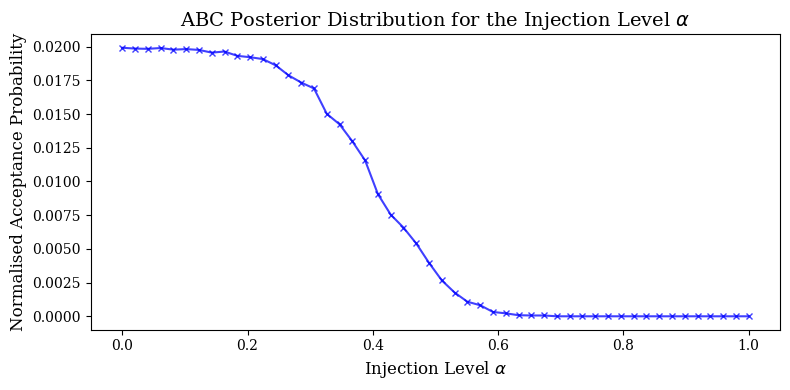

In [4]:
# EXAMPLE WITH 100 MUTATIONS, test signature is HEALTHY (alpha = 0).
importlib.reload(abc_models);
_, _ = abc_models.old_abc_alpha_inference(test_sig, healthy_profile, sbs88_profile, N_muts = 100, plot = True)

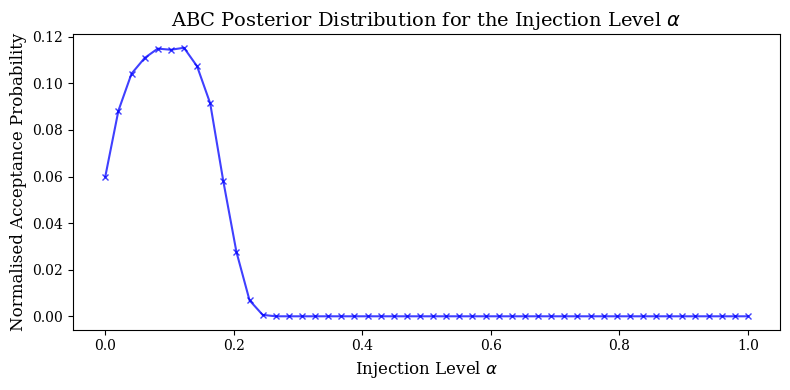

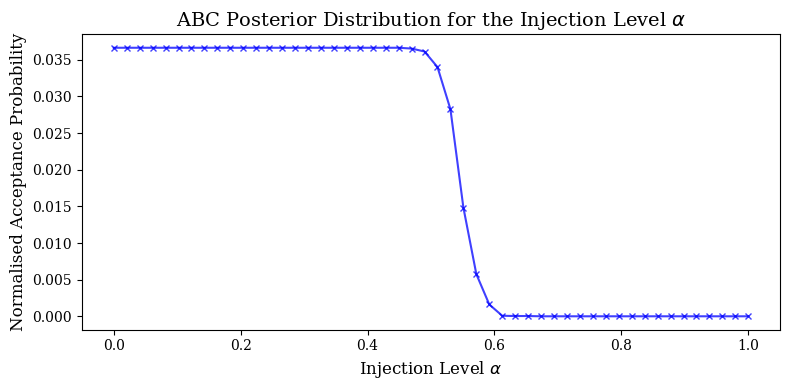

In [38]:
# ANOTHER EXAMPLE WITH 1000 MUTATIONS, TEST SIGNATURE HAS ALPHA = 0.01
# IMPORTANTLY HERE WE VARY THE TOLERANCE (IT IS IMPORTANT!)
importlib.reload(synthetic_data); importlib.reload(abc_models);
alpha01_profile = synthetic_data.composite_profile(healthy_profile, sbs88_profile, alpha = 0.1)
test_sig2 = synthetic_data.generate_signature(alpha01_profile, N_muts = 1000)

__, __ = abc_models.old_abc_alpha_inference(test_sig2, healthy_profile, sbs88_profile, N_muts = 1000, tol = 0.025, plot = True)
__, __ = abc_models.old_abc_alpha_inference(test_sig2, healthy_profile, sbs88_profile, N_muts = 1000, tol = 0.25, plot = True)

Discussion: it works as expected, but the choice of tolerance is very important. (Next section discusses how we can choose the optimal tolerance). 

To obtain more of a "classifier", or similar, we should look to construct confidence intervals for $\alpha$ arising from the posterior. If confidence interval doesn't include zero, that indicates significant evidence SBS88 is present.

---
---

#### 3. Find the optimal tolerance through TPR - FPR analysis.

Expect the tolerance to decrease as the number of mutations increases, want to see how it behaves across different alphas.

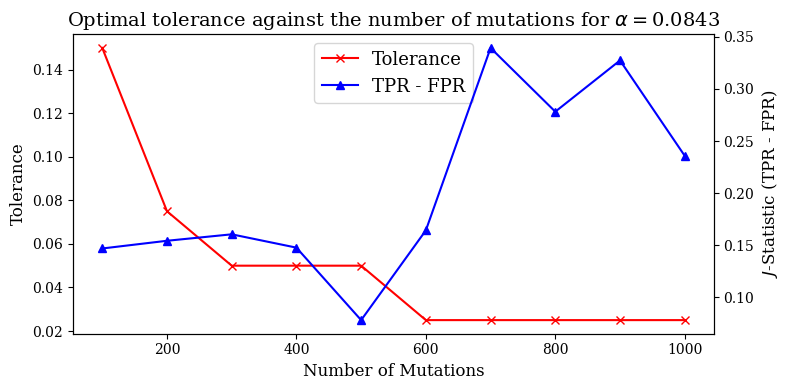

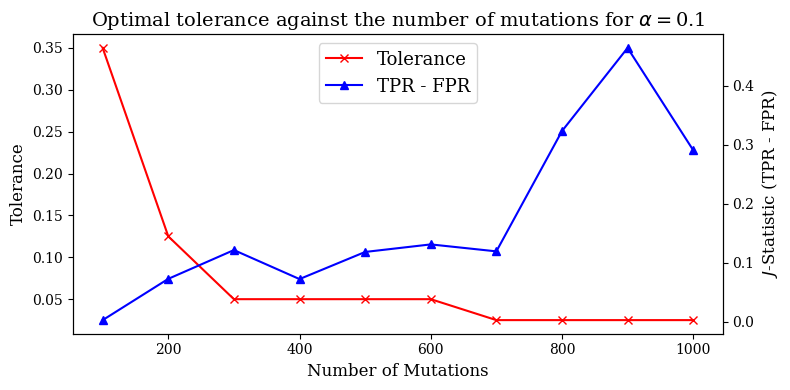

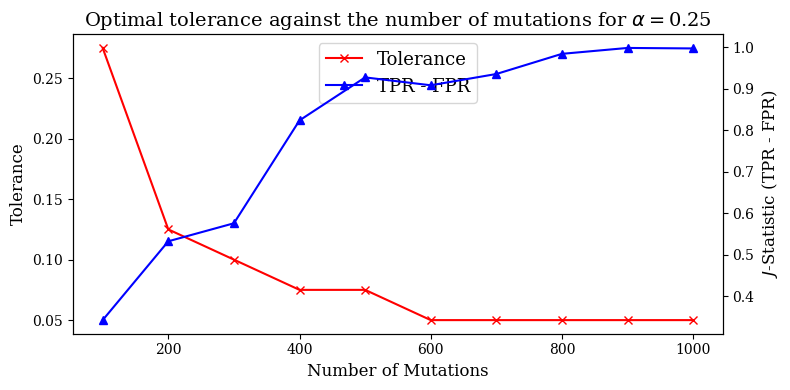

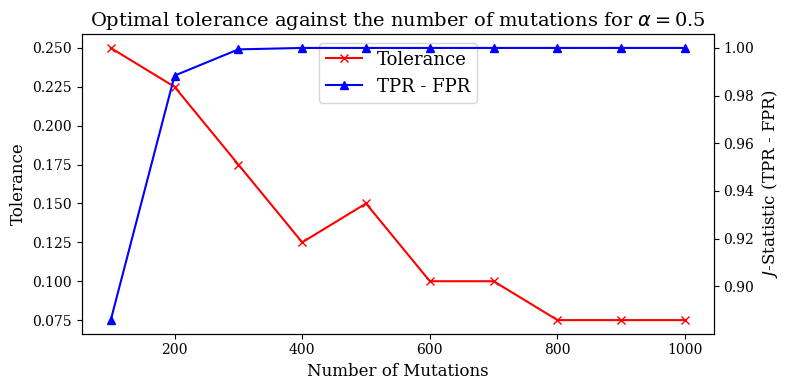

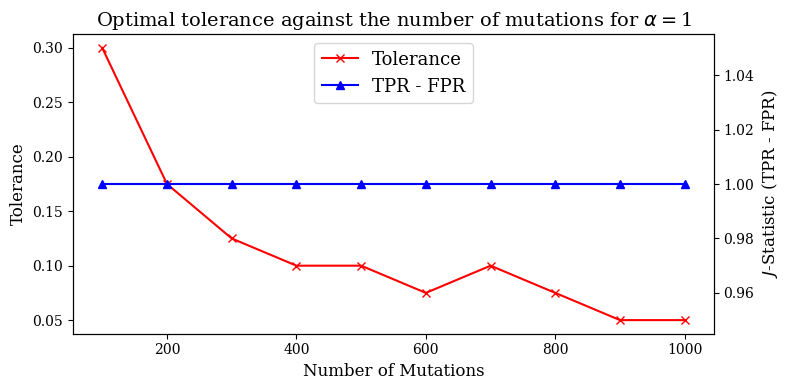

In [9]:
N_muts_range = np.arange(100, 1000 + 100, 100) # 100, 200, ..., 1000
for alpha_test in [0.0843, 0.1, 0.25, 0.5, 1]:
    abc_models.old_optimal_alpha_tol(healthy_profile, sbs88_profile, alpha_test, N_muts_range, plot = True)

In general, best tolerance decreases when we have higher resolution (higher number of mutations). Unfortunately it's very noisy for $\alpha = 0.0843$, try again with more mutations?

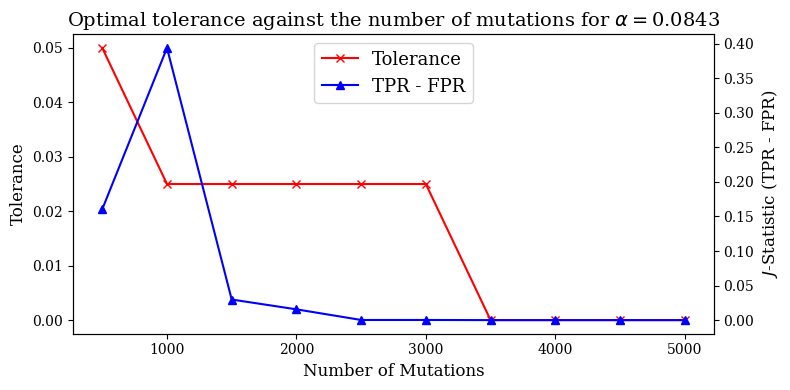

In [10]:
N_muts_alpha0843 = np.arange(500, 5000 + 500, 500)
__ = abc_models.old_optimal_alpha_tol(healthy_profile, sbs88_profile, alpha = 0.0843, N_muts_range = N_muts_alpha0843, plot = True)

Score vanishes! Why? Maybe because $\alpha$ is too low and we cannot differentiate between the signatures at all?

Plot the signatures generated from a healthy signature and a low-$\alpha$ signature to see why this might be happening?

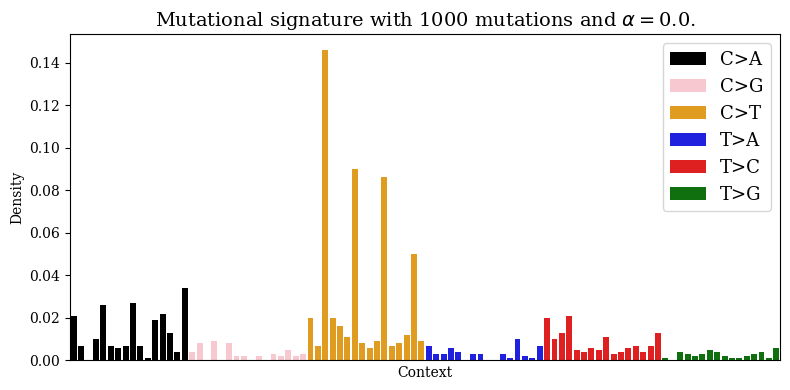

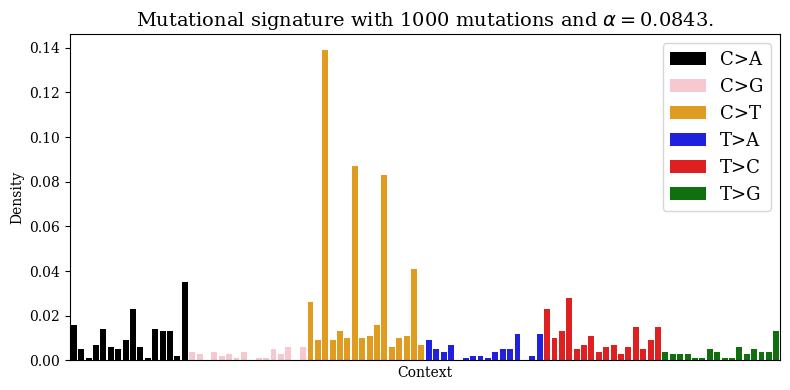

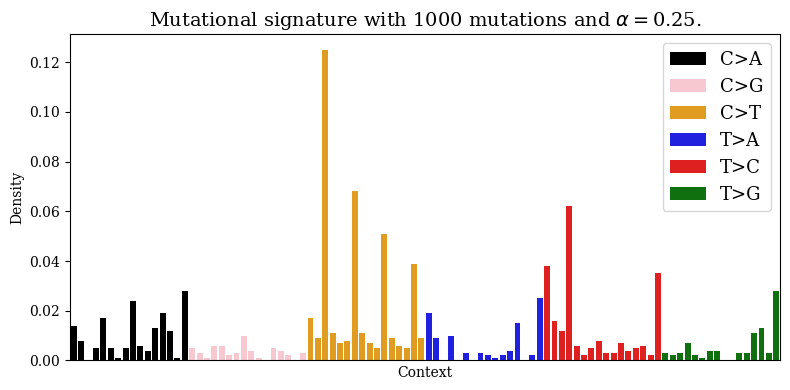

In [11]:
importlib.reload(synthetic_data);
contexts = clean_sig_df["Context"]
mutations = clean_sig_df["Mutation"]

# Infected profile alpha = 0.0843
alpha0843_profile = synthetic_data.composite_profile(healthy_profile, sbs88_profile, alpha = 0.0843)
alpha25_profile = synthetic_data.composite_profile(healthy_profile, sbs88_profile, alpha = 0.25)

N_muts = 1000
healthy_sig = synthetic_data.generate_signature(healthy_profile, N_muts)
infected_sig = synthetic_data.generate_signature(alpha0843_profile, N_muts)
infected_sig2 = synthetic_data.generate_signature(alpha25_profile, N_muts)

synthetic_data.plot_signature(contexts, mutations, healthy_sig, N_muts = 1000, alpha = 0.0)
synthetic_data.plot_signature(contexts, mutations, infected_sig, N_muts = 1000, alpha = 0.0843)
synthetic_data.plot_signature(contexts, mutations, infected_sig2, N_muts = 1000, alpha = 0.25)

Because SBS88 is dominated by T>C mutations, low levels of $\alpha$ make the signature **as a whole, across all 96 contexts** very similar. It might be worth doing the analysis **just on the T>C contexts**? Think this is something Xell suggested a few weeks ago.

Also: should store information for the mutational profiles of commonly used values of $\alpha$. Same goes for the tolerances.

In [21]:
importlib.reload(synthetic_data);
mutational_profiles = synthetic_data.create_mutational_profiles(healthy_profile, sbs88_profile)
mutational_profiles.keys()
# NOTE Should revisit the tolerance finding and save that data too
# (takes about 5mins to run).

dict_keys([0, 0.0843, 0.1, 0.25, 0.5, 0.8, 1])

#### 4. Constructing highest density intervals using ABC-alpha rejection.

Currently we can plot the posterior, but all inference is done visually. We want to have a formal metric that says "$\alpha$ is very likely to be in THIS RANGE", i.e. a form of confidence interval.

Highest density intervals (HDIs) are just narrowest range of parameters (here the smallest range of $\alpha$) that contain a certain percentage of the total probability mass (here we'll default to 90%).

True alpha =  0.25, lots of mutations (500).


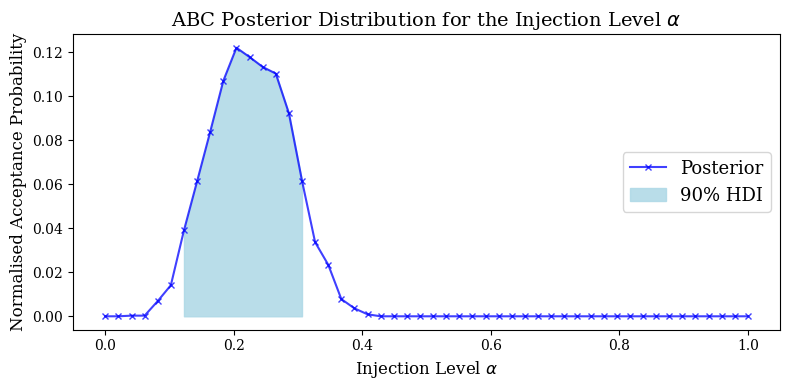

In [72]:
# EXAMPLE of posterior found from the abc-alpha.
# Tolerance found by inspection of earlier plots.
importlib.reload(abc_models);
alpha_test = 0.25; N_muts_test = 500; tol_test = 0.05;
test_sig = synthetic_data.generate_signature(mutational_profiles[alpha_test], N_muts_test)
print(rf"True alpha =  {alpha_test}, lots of mutations ({N_muts_test}).")
acceptances, alpha_range, alpha0, alpha1, alpha_mode, hdi_mass = abc_models.abc_alpha_inference(test_sig, healthy_profile, sbs88_profile, N_muts = N_muts_test, tol = tol_test, plot = True)

In [73]:
importlib.reload(abc_models);
abc_models.hdi(acceptances, alpha_range)

(np.float64(0.12244897959183673),
 np.float64(0.3061224489795918),
 np.float64(0.9088995790739628))

True alpha =  0.0843, small number of mutations (100).


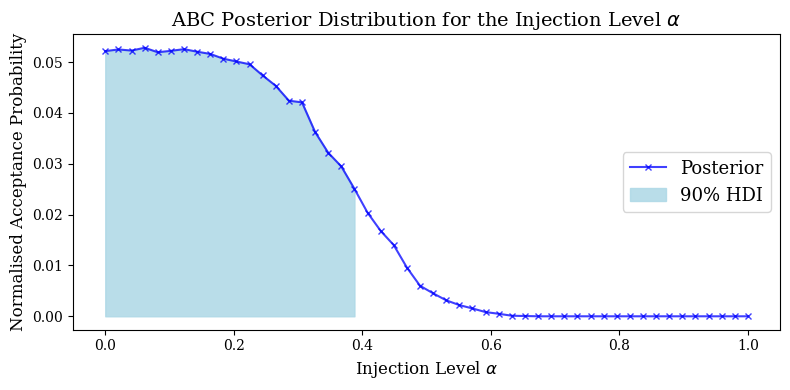

In [74]:
alpha_test = 0.0843; N_muts_test = 100; tol_test = 0.25;
test_sig = synthetic_data.generate_signature(mutational_profiles[alpha_test], N_muts_test)
print(rf"True alpha =  {alpha_test}, small number of mutations ({N_muts_test}).")
acceptances, alpha_range, alpha0, alpha1, alpha_mode, hdi_mass = abc_models.abc_alpha_inference(test_sig, healthy_profile, sbs88_profile, N_muts = N_muts_test, tol = tol_test, plot = True)

True alpha =  0.0843, very large number of mutations (2000).
In this example we use more bins for alpha (100 instead of 50).


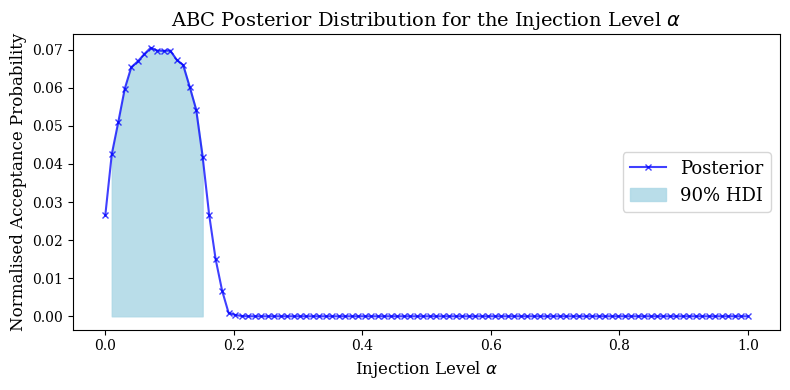

Interval [0.01, 0.15]. Mode 0.07.


In [80]:
importlib.reload(abc_models)
alpha_test = 0.0843; N_muts_test = 2000; tol_test = 0.015;
test_sig = synthetic_data.generate_signature(mutational_profiles[alpha_test], N_muts_test)
print(rf"True alpha =  {alpha_test}, very large number of mutations ({N_muts_test}).")
print(rf"In this example we use more bins for alpha (100 instead of 50).")
acceptances, alpha_range, alpha0, alpha1, alpha_mode, hdi_mass = abc_models.abc_alpha_inference(test_sig, healthy_profile, sbs88_profile, N_muts = N_muts_test, tol = tol_test, a_bins = 100, plot = True)
print(rf"Interval [{round(alpha0, 2)}, {round(alpha1, 2)}]. Mode {round(alpha_mode, 2)}.")

- In the first example, the HDI is far away from zero, so we'd detect the presence of SBS88. 
- In the second example, the HDI includes zero, but also values away from zero, so we'd be wary of detecting any SBS88.
- In the third example, we sometimes include zero, but aren't far from it. Here we'd suggest presence of SBS88 but not be *as* confident about it.

Note: have added the mode for better inference.

---

#### 5. Using the inference for classification.

First idea:
- If $0.025 < \alpha_0$ then confidently suggest the presence of SBS88. Use the mode as an estimate for the injection level.

- If $0 < \alpha_0 < 0.025$, then split into two cases: (a) if $\alpha_1 > 0.1$ AND $\alpha_{\mathrm{mode}} > 0.05$ then suggest the presence of SBS88; otherwise (b) reject.

- If $0 = \alpha_0$, reject the presence of SBS88.

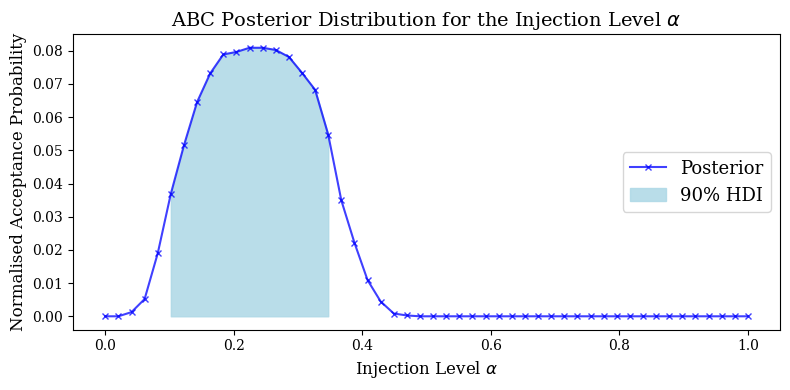

(True, np.float64(0.22448979591836732))

In [83]:
importlib.reload(abc_models);
alpha_test = 0.25; N_muts_test = 500; tol_test = 0.05;
test_sig = synthetic_data.generate_signature(mutational_profiles[alpha_test], N_muts)

abc_models.abc_alpha_classifier(test_sig, healthy_profile, sbs88_profile,
                            N_muts = N_muts_test, tol = tol_test, plot = True)

In [101]:
importlib.reload(abc_models);
alpha_test = 0.0843; N_muts_test = 100; tol_test = 0.025;
test_sig = synthetic_data.generate_signature(mutational_profiles[alpha_test], N_muts)

abc_models.abc_alpha_classifier(test_sig, healthy_profile, sbs88_profile,
                            N_muts = N_muts_test, tol = tol_test, plot = True)

c:\Users\freds\Documents\UoE\Maths\RSCAM\Project\rscam-g6\temp\abc_models.py:184: UserWarning: No value of $\alpha$ was accepted. Try adjusting the tolerance. Here tol = 0.025 with 100 mutations.
  alpha_acceptances = alpha_acceptances / alpha_acceptances.shape[0]


(False, 0.0)

---

#### 6. Use the classifier to once again find the best tolerance range.

Vary the $\alpha$ and the number of mutations presence. Here the TPR/FPR metrics make more sense since we have a genuine binary classifier.

The code went through some big changes to vectorise it.

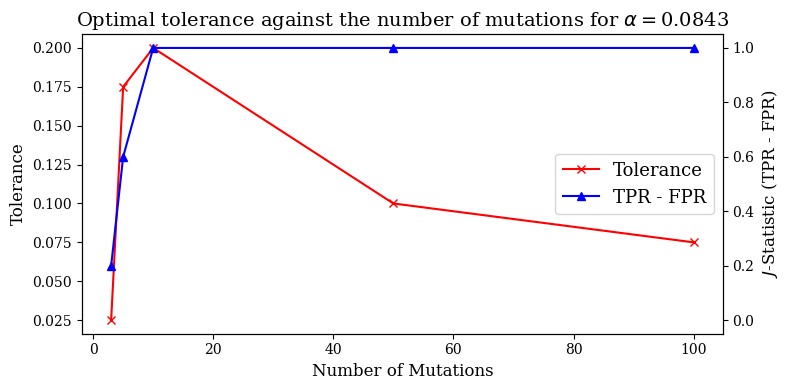

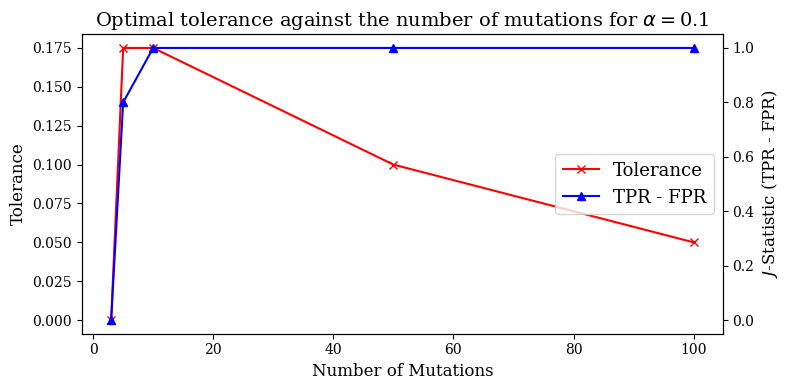

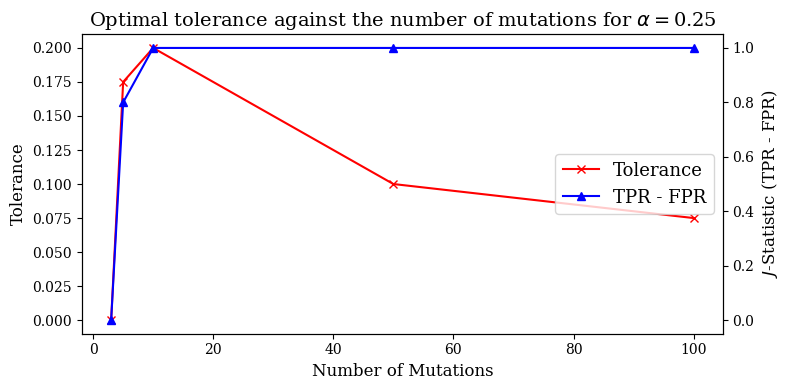

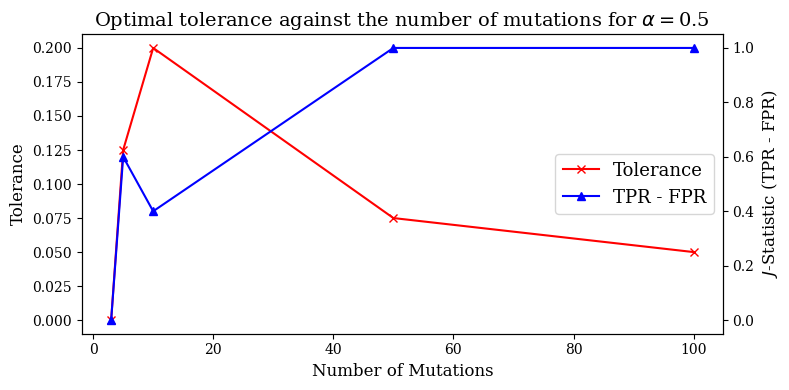

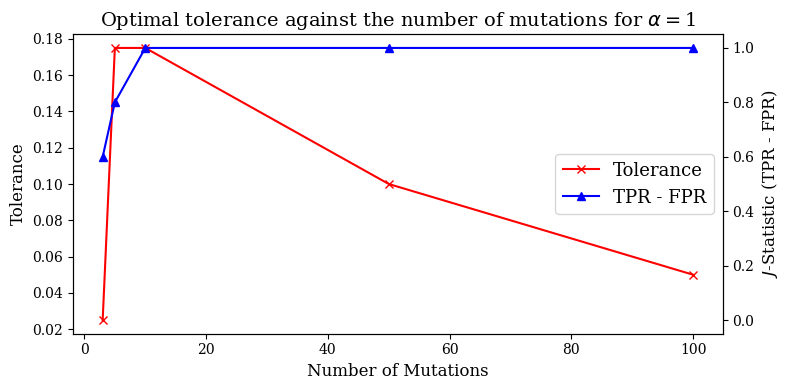

In [281]:
importlib.reload(abc_models); importlib.reload(synthetic_data);
N_muts_range = np.array([3, 5, 10, 50, 100])
# 50, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
tol_range_test = np.arange(0.025, 0.2 + 0.025, 0.025)

results_data = []
for alpha_test in [0.0843, 0.1, 0.25, 0.5, 1]:
    best_tols, best_Js = abc_models.optimal_alpha_tol(healthy_profile, sbs88_profile, alpha_test, 
                                 N_muts_range, tol_range = tol_range_test, plot = True, baseline_comparisons = 5)
    
    for n_mut, tol, j in zip(N_muts_range, best_tols, best_Js):
        results_data.append({'alpha': alpha_test, 'N_muts': n_mut, 'best_tol': tol, 'best_J': j})

results_df = pd.DataFrame(results_data)

- In `optimal_alpha_tol()`, loop over $5 \times \mathrm{tolRange} \times \mathrm{NmutsRange}$, so here $5 \times 4 \times 6 = 120$ loops per value of $\alpha$. 
- Each loop calls `abc_alpha_classifier()` twice, which in turn loops over $50$ bins of possible $\alpha$, each time calling `compare_alpha()`, which runs $B = 1000$ batches.
- So a total of a lot of loops!

One call of `abc_alpha_classsifier()` takes about 3s, so $3 \times 2 \times 120 = 720$ seconds or approx. $12$ minutes per value of $\alpha$! 

Will continue to run later.

NOTES:
- Standardise the y-axis to be between 0 and 1. 
- Can we vectorise some of the code? It's very slow and want to increase the number of baseline_comparisons from 5 to like.... 100, or 500.
- In `compare_alpha()` instead of generating the synthetic signatures at once, use the batch option in `np.multinomial()` (so change `generate_signature()`). 
- In `compare_alpha()`, use a matrix-vector formulation instead of comparing the signatures one at a time (`batch_cosine_sim()` or something).
- Use `np.mean()` to count the avgs instead of manually averaging.
- Stop generating profiles in the inner batch loop - do it once per alpha.
- Stop computing the distances for each value of the tolerance.

---
Summary: code logic remained the same, but vectorised it - much much faster, looks a bit different.


In [218]:
def best_tol(alpha, N_muts):
    return results_df.loc[(results_df["alpha"] == alpha) & (results_df["N_muts"] == N_muts), "best_tol"].item()


best_tol(0.0843, 750)

0.025

In [261]:
results_df[results_df["alpha"] == 0.1]

,alpha,N_muts,best_tol,best_J
14,0.1,3,0.125,0.2
15,0.1,5,0.175,0.2
16,0.1,10,0.100,0.2
17,0.1,50,0.200,1.0
18,0.1,100,0.075,1.0
19,0.1,200,0.050,1.0
20,0.1,300,0.050,1.0
21,0.1,400,0.025,1.0
22,0.1,500,0.025,1.0
23,0.1,600,0.025,1.0


#### 6b. Store the best tolerances and do some examples of classification with the synthetic data.

In [284]:
importlib.reload(abc_models);

# FIRST TEST: Generate synthetic signatures with alpha = 0.1 and 
# N_muts = 5, 50, 100. See if the classifier works.
alpha_test = 0.1
N_muts1 = 5
test_profile = synthetic_data.composite_profile(healthy_profile, sbs88_profile, alpha = alpha_test)
trials = 10
test_results_list = []

for _ in range(trials):
    synthetic_data.generate_signature(test_profile, N_muts = N_muts1)
    detected, estimated_alphas, n_muts = abc_models.detect_sbs88(test_sig, healthy_profile, sbs88_profile)

   # detected, estimates_alphas, n_muts = 
    # Store results in a list of dictionaries
    for j in range(len(detected)):
        test_results_list.append({
            "detected": int(detected[j]),
            "est_alpha": estimated_alphas[j],
            "N_muts": n_muts[j]})

# Convert to DataFrame
test_df = pd.DataFrame(test_results_list)

summary = test_df.groupby("N_muts").agg({
    "detected": "sum",       # Total number of detects
    "est_alpha": "mean"      # Average estimate for alpha
}).reset_index()

print(summary)

   N_muts  detected  est_alpha
0       3         0   0.000000
1       5         0   0.000000
2      10         0   0.000000
3     100         3   0.023232
4     200         0   0.000000
5     500         0   0.000000


In [288]:
importlib.reload(abc_models);

# FIRST TEST: Generate synthetic signatures with alpha = 0.1 and 
# N_muts = 5, 50, 100. See if the classifier works.
alpha_test = 0.1
N_muts1 = 200
test_profile = synthetic_data.composite_profile(healthy_profile, sbs88_profile, alpha = alpha_test)
trials = 20
test_results_list = []

for _ in range(trials):
    test_sig = synthetic_data.generate_signature(test_profile, N_muts = N_muts1)
    detected, estimated_alphas, n_muts = abc_models.detect_sbs88(test_sig, healthy_profile, sbs88_profile)

   # detected, estimates_alphas, n_muts = 
    # Store results in a list of dictionaries
    for j in range(len(detected)):
        test_results_list.append({
            "detected": int(detected[j]),
            "est_alpha": estimated_alphas[j],
            "N_muts": n_muts[j]})

# Convert to DataFrame
test_df = pd.DataFrame(test_results_list)

summary = test_df.groupby("N_muts").agg({
    "detected": "sum",       # Total number of detects
    "est_alpha": "max"      # Average estimate for alpha
}).reset_index()

print(summary)

   N_muts  detected  est_alpha
0       3         0   0.000000
1       5         1   0.121212
2      10         2   0.292929
3     100         2   0.191919
4     200         4   0.191919
5     500         3   0.191919


In [290]:
test_df[test_df["N_muts"] == 200]

,detected,est_alpha,N_muts
4,0,0.000000,200
10,0,0.000000,200
16,0,0.000000,200
22,1,0.191919,200
28,0,0.000000,200
34,0,0.000000,200
40,0,0.000000,200
46,1,0.151515,200
52,1,0.161616,200
58,0,0.000000,200


Notes:
- When aggregating, don't mean as it includes the zero values. Mean over nonzero?
- Need to implement the vectorisation for finding the optimal tolerance into the alpha inference and detection methods.
- Change the best tols to accept the largest tolerance if multiple with the same $J$ score - just swap to using >=?
- Python file is wayyy too messy. 
- Weird that even with good estimates for alpha it yields zero a lot.

---

#### 7. Work with just T>C changes instead of the whole profile?

---

#### 8. Look at the real world data, treating signatures i.i.d, and see if we can recover SBS88? 

---

In [ ]:
# Check the batch signatures work.


# Check the matrix-vector synthetic comparison works.

# Check new compare_alpha() works